# Premières étapes
## Import des packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from scipy.stats import chi2_contingency
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, confusion_matrix
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.inspection import partial_dependence, PartialDependenceDisplay, permutation_importance
from alibi.explainers import ALE, plot_ale
import lime
import lime.lime_tabular
from IPython.display import display, HTML
import shap

c:\Users\isali\Documents\cours\M2_ECAP\SVM_projet\projet_svm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Import des données

In [33]:
df = pd.read_csv('data/raw/StudentPerformanceFactors.csv')
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
# Vérification des doublons
print(df.duplicated().sum())

# Infos sur les données
df.info()

0
<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity

Pas de doublons.
6607 observations, 18 variables explicatives pour 1 variable cible : Exam_Score.
Les types des variables semblent bien correspondre aux données.
On constate la présence de valeurs manquantes dans Teacher_Quality, Parental_Education_Level, et Distance_From_Home.

## Train test split
### Séparation

In [34]:
X = df.drop(columns=["Exam_Score"])
y = df["Exam_Score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Vérification de l'équilibre de la variable cible après le split

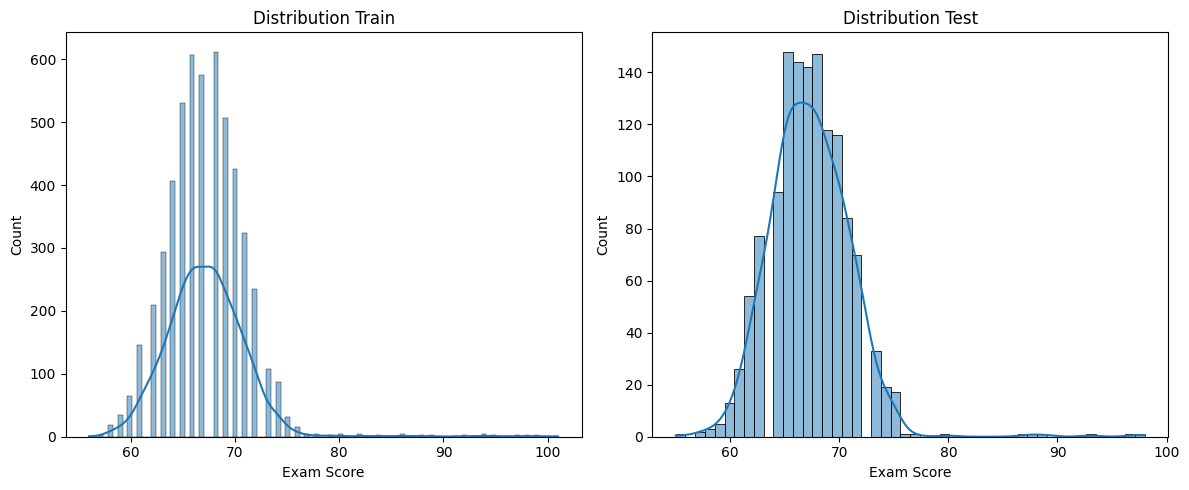

In [5]:
# Vérification sur variables numériques
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Train
sns.histplot(y_train, kde=True, ax=axes[0])
axes[0].set_title("Distribution Train")
axes[0].set_xlabel("Exam Score")

# Test
sns.histplot(y_test, kde=True, ax=axes[1])
axes[1].set_title("Distribution Test")
axes[1].set_xlabel("Exam Score")

plt.tight_layout()
plt.show()

La distribution de la variable cible semble bien équilibrée entre le jeu train et le jeu test. Le jeu test est ainsi une bonne représentation du jeu train pour la régression.

## Création d'un df train, test et concatené 

In [ ]:
# Copie des datasets
df_train = X_train.copy()
df_test = X_test.copy()

# Ajout de la target (avec reset pour éviter tout décalage)
df_train["Exam_Score"] = y_train.reset_index(drop=True)
df_test["Exam_Score"] = y_test.reset_index(drop=True)

# Ajout de la source
df_train["__source__"] = "train"
df_test["__source__"] = "test"

# Fusion
df = pd.concat([df_train, df_test], axis=0, ignore_index=True)

# Vérification
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6607 non-null   int64  
 1   Attendance                  6607 non-null   int64  
 2   Parental_Involvement        6607 non-null   str    
 3   Access_to_Resources         6607 non-null   str    
 4   Extracurricular_Activities  6607 non-null   str    
 5   Sleep_Hours                 6607 non-null   int64  
 6   Previous_Scores             6607 non-null   int64  
 7   Motivation_Level            6607 non-null   str    
 8   Internet_Access             6607 non-null   str    
 9   Tutoring_Sessions           6607 non-null   int64  
 10  Family_Income               6607 non-null   str    
 11  Teacher_Quality             6529 non-null   str    
 12  School_Type                 6607 non-null   str    
 13  Peer_Influence              6607 non-null   

In [22]:
# Copie de X_train et X_test en DataFrame 
df_train = pd.DataFrame(X_train, columns=X.columns)
df_test = pd.DataFrame(X_test, columns=X.columns)

# Création d'une colonne source pour différencier les données
df_train["__source__"] = "train"
df_test["__source__"] = "test"

# Fusion des deux datasets
df = pd.concat([df_train, df_test], axis=0, ignore_index=True)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

## Traitement des valeurs manquantes 
Tout ce qui dépend de statistiques (taux de NA, colonnes à drop, catégories à ajouter) doit être calculé uniquement sur le train, afin d'éviter le data leakage.
Les règles appliquées sur le train seront ensuite appliquées sur le test.

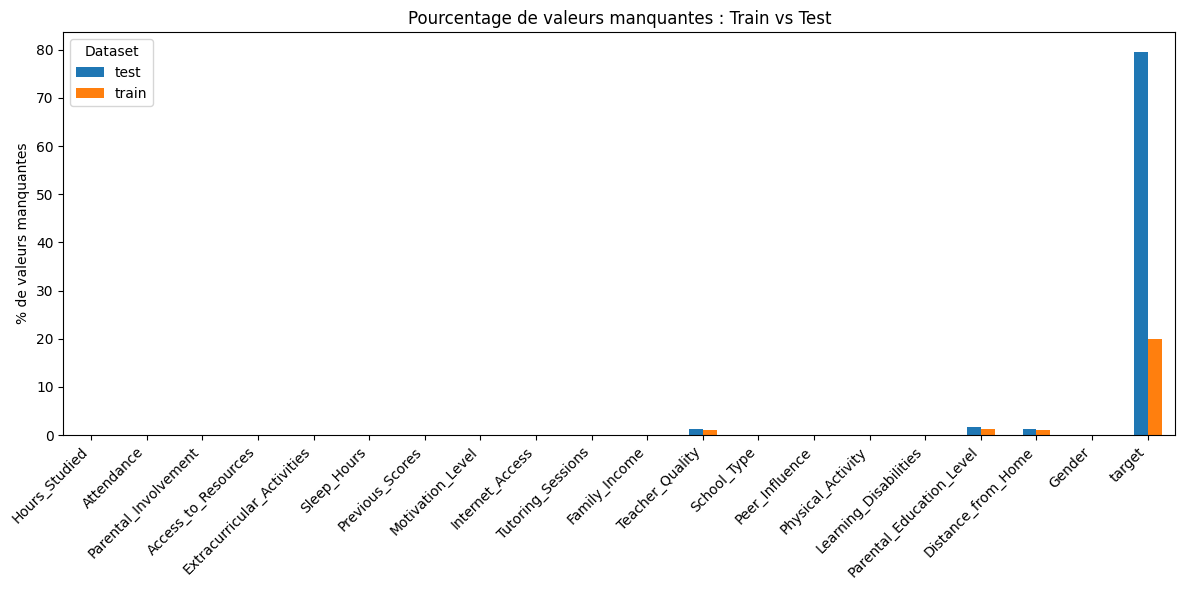

In [36]:
# Calcul du % de valeurs manquantes par colonne et par source
missing_pct = (
    df.groupby("__source__")
      .apply(lambda x: x.isna().mean() * 100)
      .T  # transpose pour avoir les variables en index
)

# Figure
missing_pct.plot(kind="bar", figsize=(12,6))

plt.title("Pourcentage de valeurs manquantes : Train vs Test")
plt.ylabel("% de valeurs manquantes")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

Le pourcentage de valeurs manquantes par variable étant très faibles pour chacune des colonnes concernées, nous pouvons remplacer ces valeurs.

In [8]:
# Colonnes avec valeurs manquantes
missing_cols = ["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]

# Initialisation de l'imputation avec la modalité la plus fréquente
cat_imputer = SimpleImputer(strategy="most_frequent")

# FIT uniquement sur le train
cat_imputer.fit(df_train[missing_cols])

# TRANSFORM sur train et test
df_train[missing_cols] = cat_imputer.transform(df_train[missing_cols])
df_test[missing_cols] = cat_imputer.transform(df_test[missing_cols])

# Reconstruction du df complet après nettoyage des valeurs manquantes
df = pd.concat([df_train, df_test], axis=0, ignore_index=True)

# Vérification des valeurs manquantes après imputation
print(df.isna().sum())

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
__source__                    0
dtype: int64


# Feature Engineering
## Création de variables
Afin d'améliorer l'éfficacité de notre modèle, nous testerons l'ajout de nouvelles variables crées à partir de nos variables actuelles ou avec intéractions.

In [9]:
# Indice de performance globale étudiant
#df["Student_Score_Index"] = (
#    df["Hours_Studied"] +
#    df["Attendance"] +
#    df["Previous_Scores"]
#) / 3

# Score d'effort
#df["Effort_Score"] = df["Hours_Studied"] * df["Motivation_Level"]

# Score de support parentale
#df["Support_Score"] = (
#    df["Access_to_Resources"] +
#    df["Parental_Education_Level"]
#)

# Contexte parentale
df["Parent_Context"] = (
    df["Parental_Education_Level"].astype(str) + "_" +
    df["Family_Income"].astype(str)
)

# Efficacité du travail
df["Efficiency"] = df["Previous_Scores"] / (df["Hours_Studied"] + 1)

# Vérification
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6607 non-null   int64  
 1   Attendance                  6607 non-null   int64  
 2   Parental_Involvement        6607 non-null   str    
 3   Access_to_Resources         6607 non-null   str    
 4   Extracurricular_Activities  6607 non-null   str    
 5   Sleep_Hours                 6607 non-null   int64  
 6   Previous_Scores             6607 non-null   int64  
 7   Motivation_Level            6607 non-null   str    
 8   Internet_Access             6607 non-null   str    
 9   Tutoring_Sessions           6607 non-null   int64  
 10  Family_Income               6607 non-null   str    
 11  Teacher_Quality             6607 non-null   str    
 12  School_Type                 6607 non-null   str    
 13  Peer_Influence              6607 non-null   

Ces ajouts ne sont pas fait à partir des statistiques globales, et peuvent donc être fait directement sur le df complet.
Nous devons néanmoins re découper le df en train et test à partir de la colonne source, afin d'appliquer ces modifications.

In [10]:
# Split train/test depuis le df complet 
df_train = df[df["__source__"] == "train"].copy()
df_test = df[df["__source__"] == "test"].copy()

# Vérification 
print(df.info())
print(df_train.info())
print(df_test.info())

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6607 non-null   int64  
 1   Attendance                  6607 non-null   int64  
 2   Parental_Involvement        6607 non-null   str    
 3   Access_to_Resources         6607 non-null   str    
 4   Extracurricular_Activities  6607 non-null   str    
 5   Sleep_Hours                 6607 non-null   int64  
 6   Previous_Scores             6607 non-null   int64  
 7   Motivation_Level            6607 non-null   str    
 8   Internet_Access             6607 non-null   str    
 9   Tutoring_Sessions           6607 non-null   int64  
 10  Family_Income               6607 non-null   str    
 11  Teacher_Quality             6607 non-null   str    
 12  School_Type                 6607 non-null   str    
 13  Peer_Influence              6607 non-null   

# Nettoyage et visualisation des données
## Création de listes de variables en fonction du type

In [23]:
# Colonnes quantitatives (numériques)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Colonnes qualitatives catégorielles (texte)
cat_cols = df.select_dtypes(include=['str']).columns.tolist()

## Création d'une palette de couleurs

In [12]:
palette = sns.color_palette("pastel", 10)

## Analyse descriptives univariées
### Variables numériques

In [24]:
# Statistiques descriptives
df.describe() 

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000


Les moyennes sont proches des médianes, ce qui indique des distributions plutôt normales.

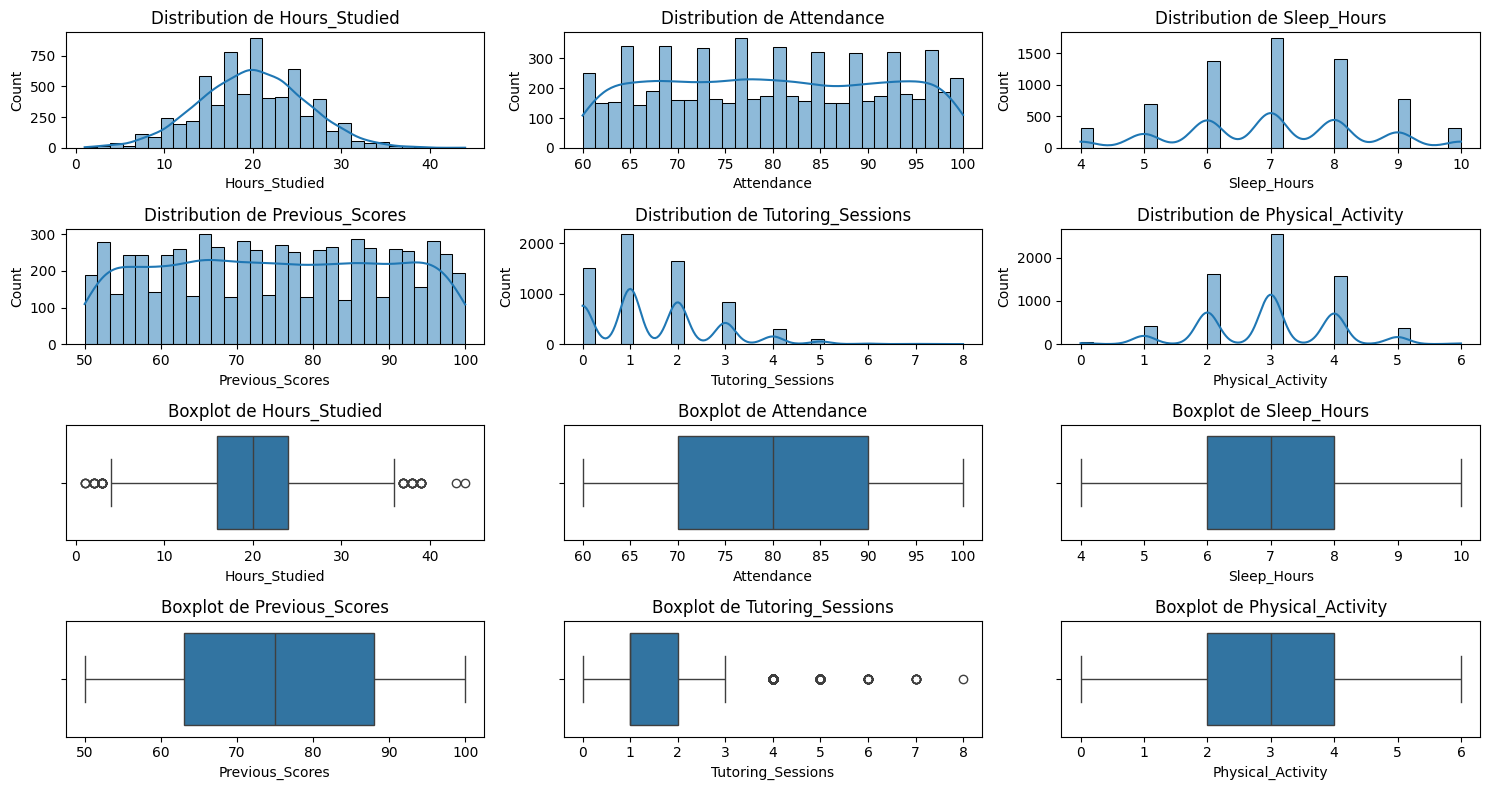

In [25]:
# Histogrammes et Boxplots 

num_cols = df.select_dtypes(include=[np.number]).columns
n_vars = len(num_cols)
n_cols = 3
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(
    2 * n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    squeeze=False
)

for i, col in enumerate(num_cols):
    # Indices de ligne / colonne
    row = i // n_cols
    col_idx = i % n_cols

    # Histogramme
    ax_hist = axes[row, col_idx]
    sns.histplot(df[col], bins=30, kde=True, ax=ax_hist)
    ax_hist.set_title(f"Distribution de {col}")

    # Boxplot
    ax_box = axes[row + n_rows, col_idx]
    sns.boxplot(x=df[col], ax=ax_box)
    ax_box.set_title(f"Boxplot de {col}")

# Masque les axes vides
for j in range(n_vars, n_rows * n_cols):
    r = j // n_cols
    c = j % n_cols
    axes[r, c].axis("off")
    axes[r + n_rows, c].axis("off")

plt.tight_layout()
plt.show()

Les distributions des variables quantitatives semblent suivre la Loi Normale, à l'exception de *Attendance*, *Previous_Score* et *Efficiency*.
On observe la présence de potentielles valeurs extrêmes dans *Hours_Studied*, *Tutoring_Sessions*, *Exam_Score* et *Efficiency*.

#### Traitement des valeurs extrêmes

In [26]:
num_cols = df_train.select_dtypes(include=["int64", "float64"]).columns
quantiles = {}

# calcul uniquement sur les variables numériques
for col in num_cols:
    low = df_train[col].quantile(0.01)
    high = df_train[col].quantile(0.99)
    quantiles[col] = (low, high)
    n_changed = ((df_train[col] < quantiles[col][0]) | 
                 (df_train[col] > quantiles[col][1])).sum()
    
    print(f"{col}: {n_changed} valeurs modifiées")

def apply_winsorization(df, quantiles):
    df = df.copy()
    for col, (low, high) in quantiles.items():
        df[col] = df[col].clip(low, high)
    return df

# Application de la winsorization sur les jeux d'entraînement et de test
df_train = apply_winsorization(df_train, quantiles)
df_test  = apply_winsorization(df_test, quantiles)

# Reconstruction du df complet après nettoyage des valeurs extrêmes
df = pd.concat([df_train, df_test], axis=0, ignore_index=True)

Hours_Studied: 87 valeurs modifiées
Attendance: 0 valeurs modifiées
Sleep_Hours: 0 valeurs modifiées
Previous_Scores: 52 valeurs modifiées
Tutoring_Sessions: 24 valeurs modifiées
Physical_Activity: 59 valeurs modifiées


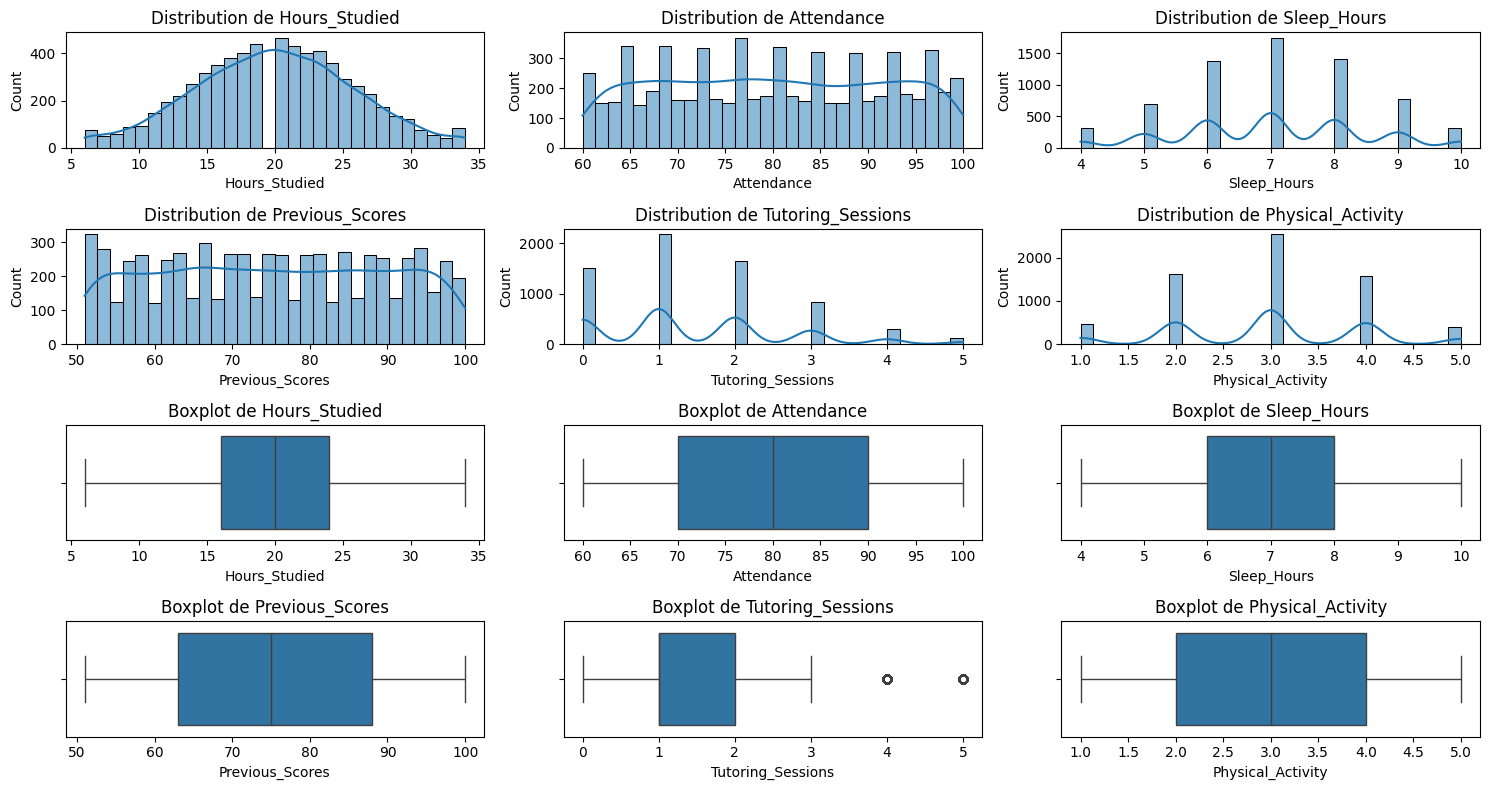

In [27]:
# Histogrammes et Boxplots après traitements des outliers

#num_cols = df.select_dtypes(include=[np.number]).columns
n_vars = len(num_cols)
n_cols = 3
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(
    2 * n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    squeeze=False
)

for i, col in enumerate(num_cols):
    # Indices de ligne / colonne
    row = i // n_cols
    col_idx = i % n_cols

    # Histogramme
    ax_hist = axes[row, col_idx]
    sns.histplot(df[col], bins=30, kde=True, ax=ax_hist)
    ax_hist.set_title(f"Distribution de {col}")

    # Boxplot
    ax_box = axes[row + n_rows, col_idx]
    sns.boxplot(x=df[col], ax=ax_box)
    ax_box.set_title(f"Boxplot de {col}")

# Masque les axes vides
for j in range(n_vars, n_rows * n_cols):
    r = j // n_cols
    c = j % n_cols
    axes[r, c].axis("off")
    axes[r + n_rows, c].axis("off")

plt.tight_layout()
plt.show()

Les distributions semblent davantage suivre la Loi Normale et la majorité des potentielles valeurs atypiques ont disparu, sauf pour *Efficiency* pour laquelle nous constatons qu'il y a toujours un nombre important de valeurs s'écartant de la médiane.

### Variables catégorielles

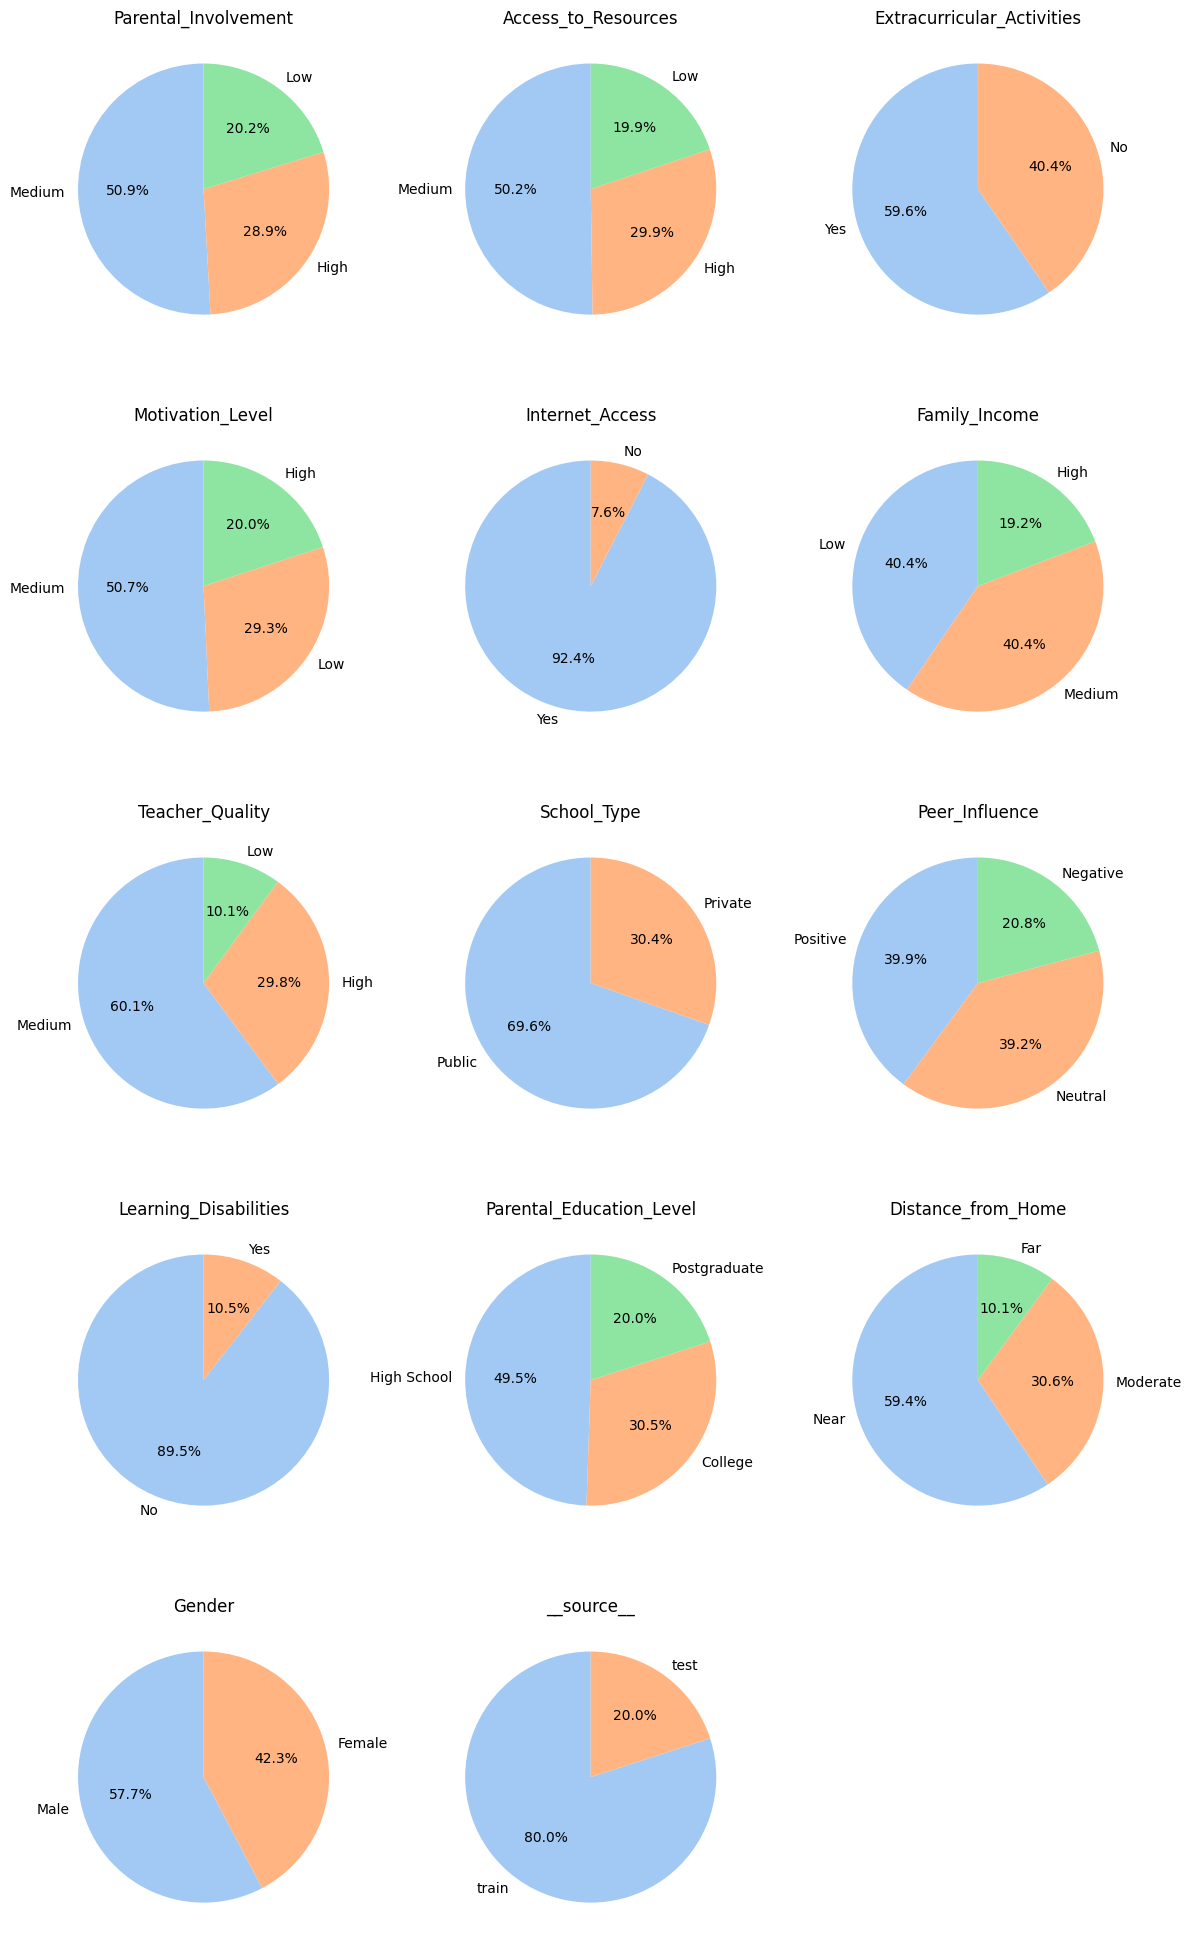

In [28]:
# Pie Chart pour variables catégorielles
def plot_pie(data, columns):

    n_cols = 3
    n_rows = (len(columns) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows*4))
    axes = axes.flatten()

    for i, col in enumerate(columns):

        counts = data[col].value_counts()

        axes[i].pie(
            counts.values,
            labels=counts.index,
            autopct='%1.1f%%',
            startangle=90,
            colors=palette
        )

        axes[i].set_title(col)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Affichage 
plot_pie(df, cat_cols)

La plupart des variables catégorielles ne montrent pas la présence de modalités avec un très faible pourcentage de valeurs. Néanmoins, la variable Parent_Context contient de nombreuses modalités, dont certaines représentant moins de 6% des observations. Nous pouvons alors regrouper ces catégories entre elles, pour améliorer la pertinence de la variable et ainsi, la performance des modèles. 

### Regroupement Parent_Context

In [19]:
# Colonne à traiter
col = "Parent_Context"
threshold = 0.06

# Conversion de col en variable catégorielle dans df_train 
df_train[col] = df_train[col].astype("category")

# Calcul des catégories rares (uniquement sur train)
freq = df_train[col].value_counts(normalize=True)
rare_categories = freq[freq < threshold].index

# Ajout de "Autres"
df_train[col] = df_train[col].cat.add_categories("Autres")

# Remplacement des rares
df_train[col] = df_train[col].replace(rare_categories, "Autres")

# Plot après regroupement
plot_pie(df_train, ["Parent_Context"])

ValueError: new categories must not include old categories: {'Autres'}

In [ ]:
# Application du même traitement sur le test
df_test[col] = df_test[col].astype("category")
df_test[col] = df_test[col].cat.add_categories("Autres")
df_test[col] = df_test[col].replace(rare_categories, "Autres")

In [ ]:
# Concaténation du df complet après regroupement des catégories rares
df = pd.concat([df_train, df_test], axis=0, ignore_index=True)
df.info()

### Corrélations entre variables explicatives numériques

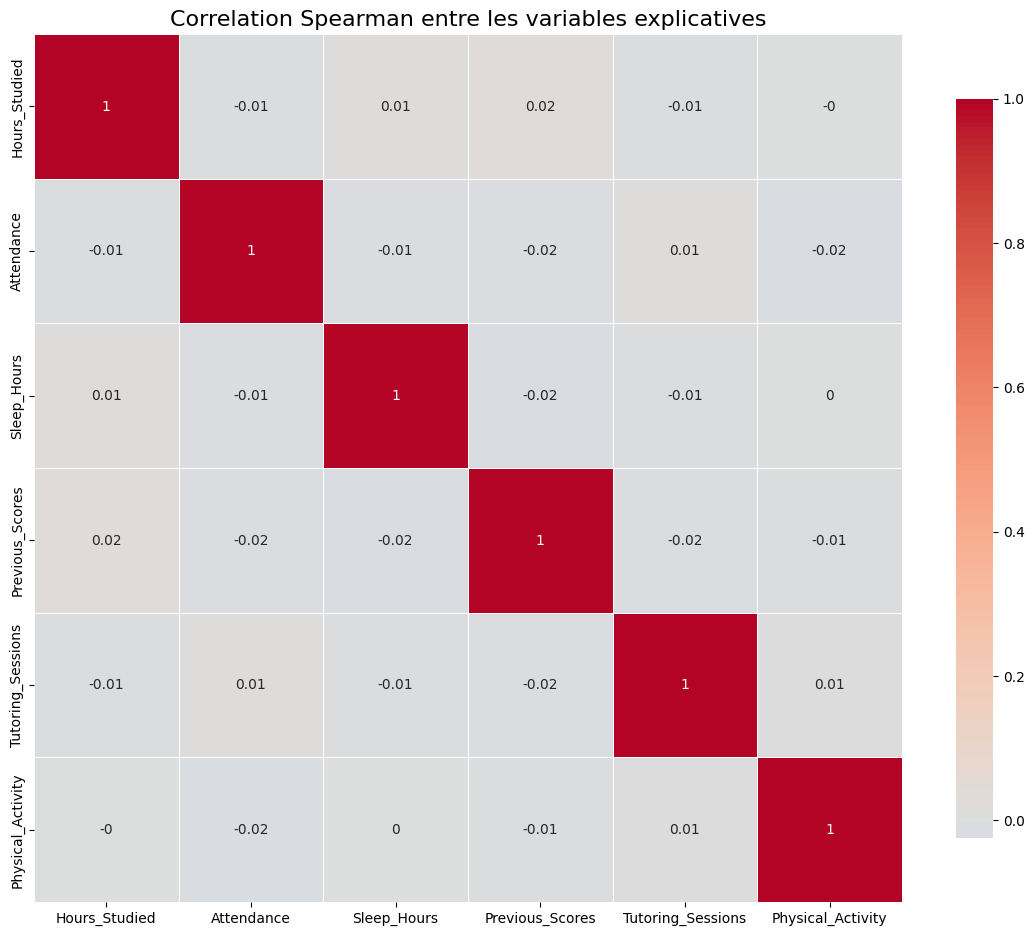

In [29]:
# Correlation map avec spearman entre les variables explicatives
# Exclusion de la variable cible
x_cols = [c for c in num_cols if c != "Exam_Score"]

# Application de la méthode de corrélation de Spearman
corr = df[x_cols].corr(method='spearman')

# Figure
plt.figure(figsize=(14,12))
sns.heatmap(corr, annot=corr.round(2), cmap="coolwarm", center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Correlation Spearman entre les variables explicatives", fontsize=16)
plt.show()

Le jeu de données étant fictif, nous retrouvons uniquement des corrélations quasiment inexistantes pour les variables de base. Cela ne pose pas de problème pour la réalisation de modèles de regréssions mais cela limite néanmoins le réalisme de ce dataset et donc des résultats que nous obtiendrons.
Nous trouvons néanmoins des corrélations plus importantes pour les variables que nous avons créees, notament pour Student_Score_Index, avec Previous_Score.

### Corrélation entre variables qualitatives

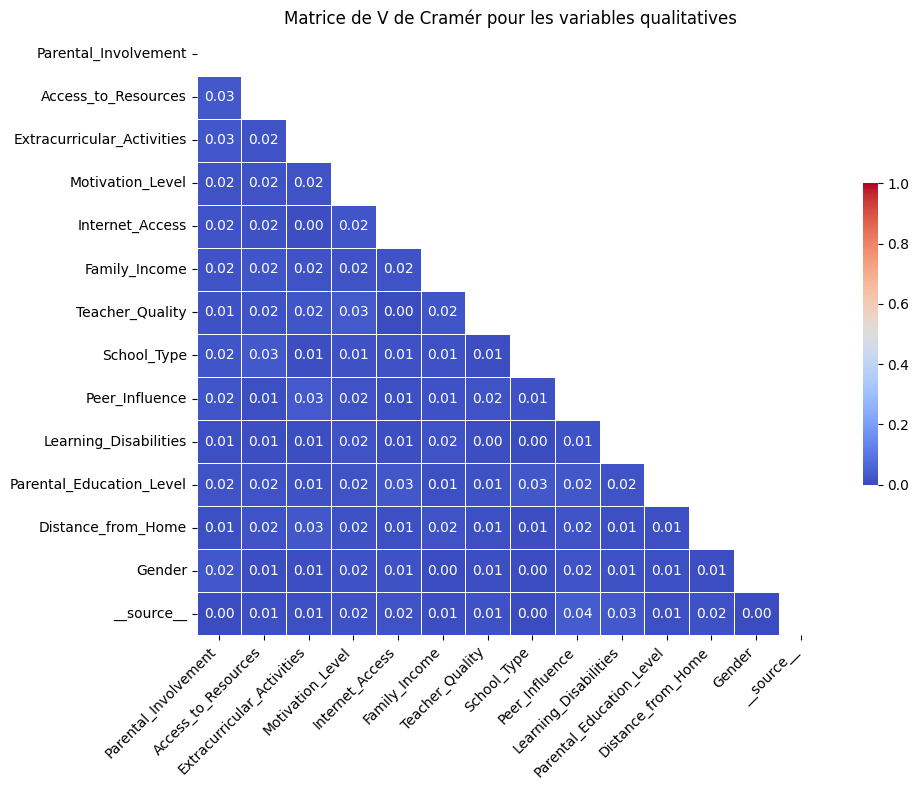

In [30]:
# Matrice de V de Cramer sous forme de heatmap

# Conversion de Parent_Context en string pour faciliter l'analyse
#df["Parent_Context"] = df["Parent_Context"].astype("str")
#df_train["Parent_Context"] = df_train["Parent_Context"].astype("str")
#df_test["Parent_Context"] = df_test["Parent_Context"].astype("str")

# Liste des variables catégorielles à analyser
cat_cols = df.select_dtypes(include=['str']).columns.tolist()

# Création de la matrice de V de Cramer
def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    
    return np.sqrt(chi2 / (n * (min(r-1, k-1))))

cramer_matrix = pd.DataFrame(
    np.zeros((len(cat_cols), len(cat_cols))),
    index=cat_cols,
    columns=cat_cols
)

for col1 in cat_cols:
    for col2 in cat_cols:
        cramer_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

## Figure et Heatmap
### Masque pour le triangle supérieur
mask = np.triu(np.ones_like(cramer_matrix, dtype=bool))

### Affichage
plt.figure(figsize=(10, 8))
sns.heatmap(
    cramer_matrix.astype(float),
    mask=mask,
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    center=0.5,
    annot=True,
    fmt=".2f",
    linewidths=.5,
    cbar_kws={"shrink": 0.5},
    annot_kws={"size": 10}
)

plt.title("Matrice de V de Cramér pour les variables qualitatives")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

De la même façon que pour les variables numériques, il n'existe que des corrélations extremement faibles entre les variables qualitatives. 
Sauf pour Parent_Context qui est logiquement parfaitement corrélé avec Family_Income et Parental_Education_Level. 
Dans le cas inverse, nous aurions pu sélectionner les variables à inclure dans notre modèle de telle sorte à ce qu'il n'existe pas de variables fortement corrélées entre elles. Cela pourrait notamment se faire en supprimant une à une les variables les plus corrélées à d'autres, puis en recalculant les corrélations après chaque suppression, jusqu'à ce qu'il n'existe plus de corrélations fortes, supérieures à 0,8 ou 0,7. 

### Analyse des relations entre variables quantitatives et la variables cible

In [31]:
# Corrélation entre les variables explicatives numériques et la variable cible
corr_target = df[x_cols + ["Exam_Score"]].corr(method="spearman")["Exam_Score"].drop("Exam_Score").sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=corr_target.values, y=corr_target.index, palette=palette)
plt.title("Corrélation Spearman entre les features numériques et Exam_Score", fontsize=14)
plt.xlabel("Coefficient de corrélation")
plt.show()

KeyError: "['Exam_Score'] not in index"

## Analyse descriptive multivariée
### Analyse des relations entre variables qualitatives et la variable cible

C:\Users\isali\AppData\Local\Temp\ipykernel_88136\1519432884.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\isali\AppData\Local\Temp\ipykernel_88136\1519432884.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\isali\AppData\Local\Temp\ipykernel_88136\1519432884.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\isali\AppData\Local\Temp\ipykernel_88136\1519432884.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

<Figure size 1400x3000 with 0 Axes>

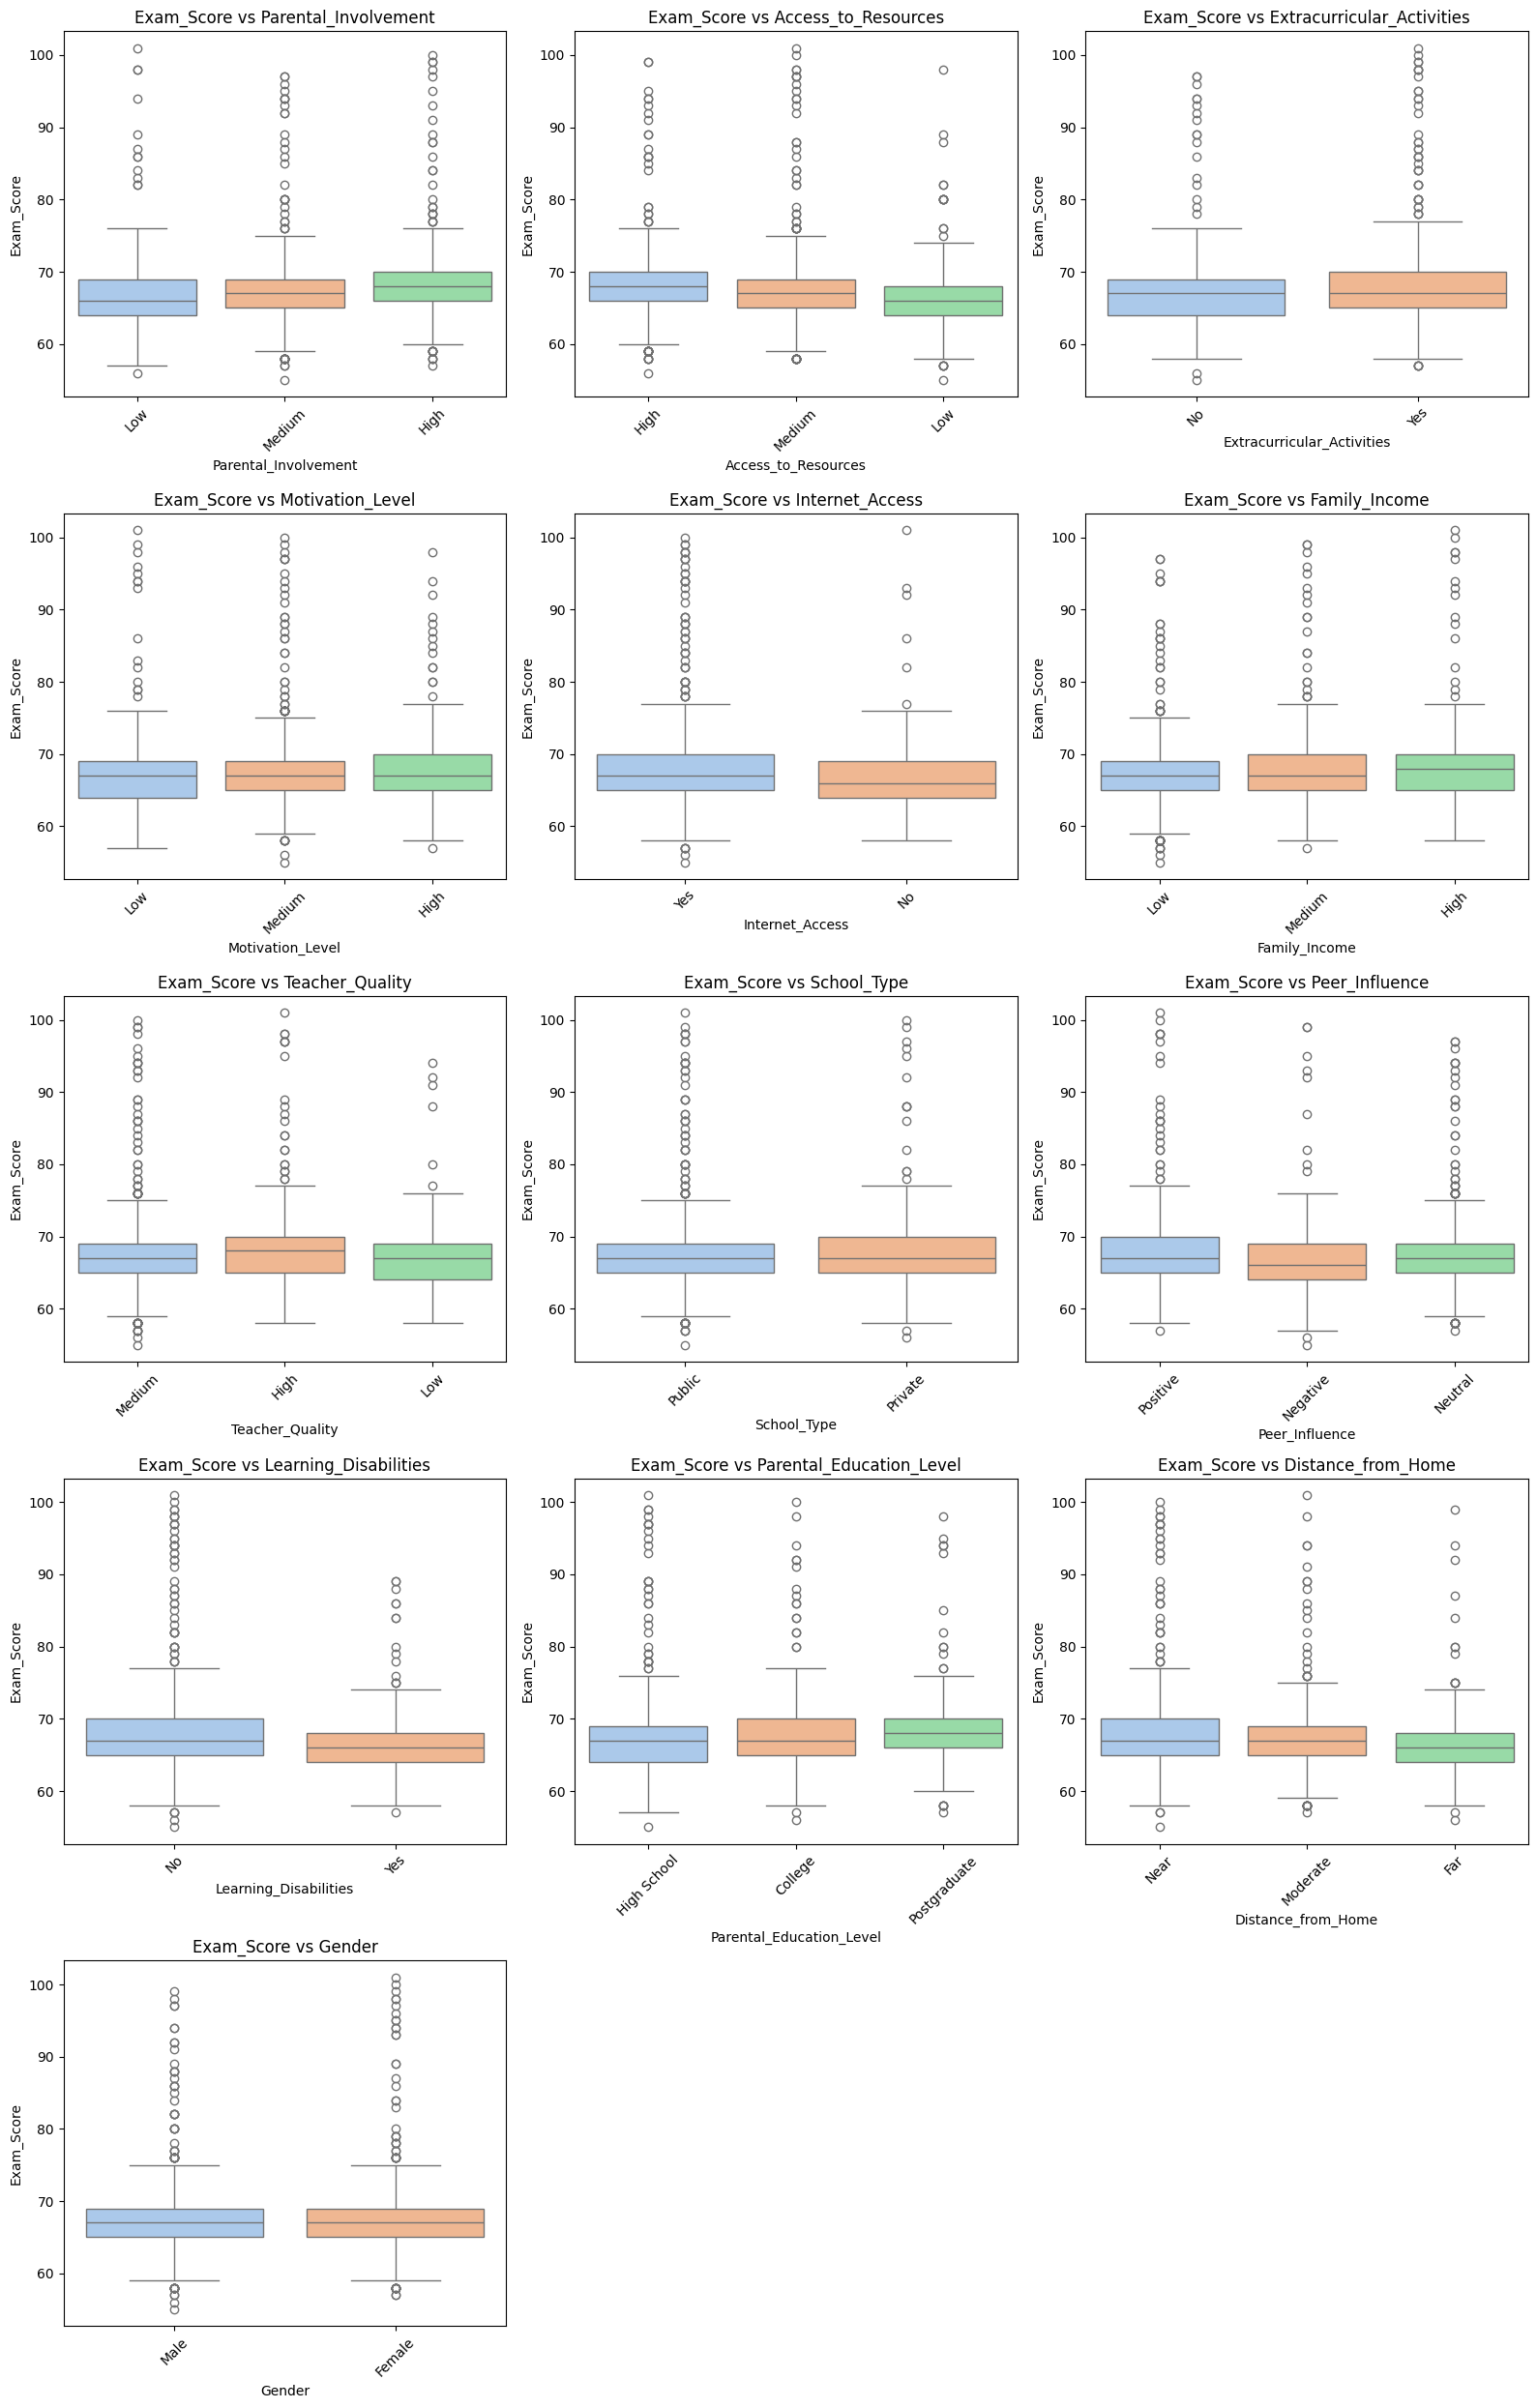

In [16]:
plt.figure(figsize=(14, 30))

# Nombre de variables qualitatives
n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*5))
axes = axes.flatten()

for i, cat in enumerate(cat_cols):
    sns.boxplot(
        data=df,
        x=cat,
        y="Exam_Score",
        ax=axes[i],
        palette="pastel"
    )
    axes[i].set_title(f"Exam_Score vs {cat}")
    axes[i].tick_params(axis="x", rotation=45)

# Supprimer les axes vides si le nombre de sous-plots dépasse le nombre de variables
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Traitements avant modélisation
## Normalisation des features

In [ ]:
# Reconstruction des X_train et X_test après imputation et transformations
X_train = df_train.drop(columns=["__source__"])
X_test = df_test.drop(columns=["__source__"])

scaler = StandardScaler()
scaler.fit(X_train_rl)

X_train_sc = scaler.transform(X_train_rl)
X_test_sc = scaler.transform(X_test_rl)

print(X_train_sc.shape, X_test_sc.shape, y_train.shape, y_test.shape)

## Encodage des variables catégorielles

# Modélisation
## Modèles baselines

## Optimisation des hyper paramètres

# Interprétation du meilleur modèle